<a href="https://colab.research.google.com/github/cpatterson71/Great_Learning_Project_Easy_Visa/blob/main/Project_Full_Code_Notebook_EasyVisa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 8.3 MB/s eta 0:00:00


**Note**:
* After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
* On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in **this notebook**.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Loading the dataset**

In [1]:
import pandas as pd

# Load the dataset into a pandas DataFrame
# Replace 'EasyVisa.csv' with the exact filename or path if it's different
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/EasyVisa.csv')

# Display the first 5 rows to confirm it loaded correctly
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/EasyVisa.csv'

# **Overview of the Dataset**

* Observations

* Sanity checks

# **Exploratory Data Analysis (EDA)**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?


**[IMPORTANT]** Beyond the Basics: Please note that these are guiding questions only. To receive full points for this rubric section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

/tmp/ipykernel_8506/1762903838.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='case_status', palette='Set2')


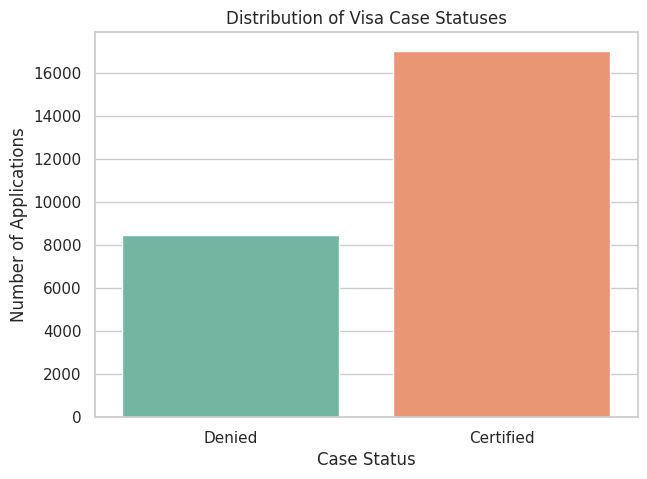

case_status
Certified    66.789639
Denied       33.210361
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for plots
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='case_status', palette='Set2')
plt.title('Distribution of Visa Case Statuses')
plt.xlabel('Case Status')
plt.ylabel('Number of Applications')
plt.show()

# Print percentages
print(df['case_status'].value_counts(normalize=True) * 100)

# **Data Pre-processing**

- Missing value treatment (check if needed)
- Outlier detection and treatment (check if needed)
- Feature engineering (check if needed)
- Preparing data for modeling
- Any other preprocessing steps (check if needed)

# **Model Building - Original Data**

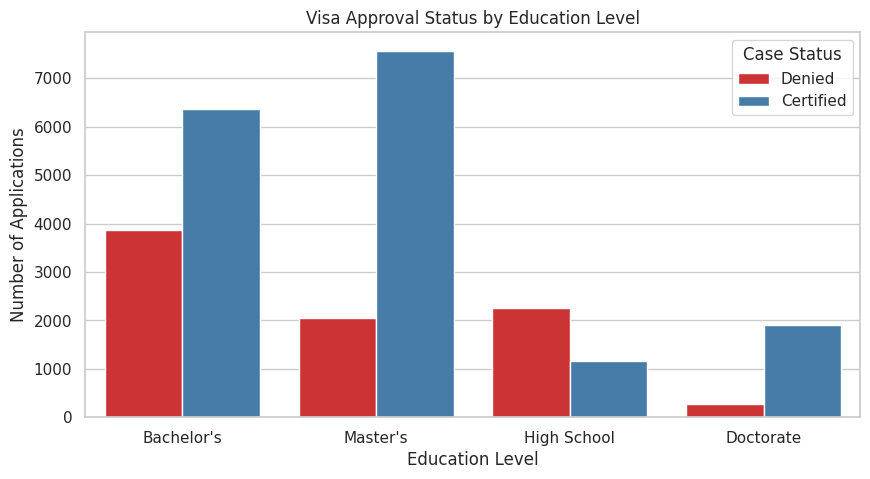

--- Education Level Approval Percentages ---
case_status            Certified     Denied
education_of_employee                      
Bachelor's             62.214188  37.785812
Doctorate              87.226277  12.773723
High School            34.035088  65.964912
Master's               78.627777  21.372223




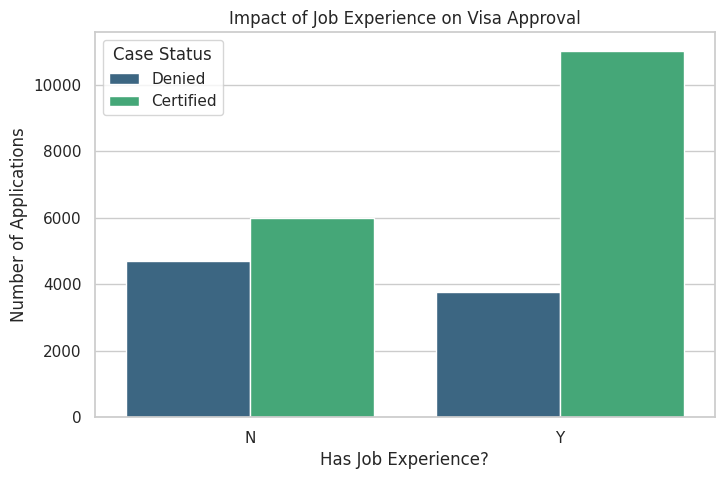

--- Job Experience Approval Percentages ---
case_status         Certified     Denied
has_job_experience                      
N                   56.134108  43.865892
Y                   74.476422  25.523578


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for plots
sns.set_theme(style="whitegrid")

# 1. Education Level vs. Visa Approval Rates
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='education_of_employee', hue='case_status', palette='Set1',
              order=df['education_of_employee'].value_counts().index)
plt.title('Visa Approval Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)
plt.legend(title='Case Status')
plt.show()

# Show exact cross-tabulation percentages for education
print("--- Education Level Approval Percentages ---")
print(pd.crosstab(df['education_of_employee'], df['case_status'], normalize='index') * 100)
print("\n" + "="*50 + "\n")

# 2. Job Experience vs. Visa Approval Rates
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='has_job_experience', hue='case_status', palette='viridis')
plt.title('Impact of Job Experience on Visa Approval')
plt.xlabel('Has Job Experience?')
plt.ylabel('Number of Applications')
plt.legend(title='Case Status')
plt.show()

# Show exact cross-tabulation percentages for job experience
print("--- Job Experience Approval Percentages ---")
print(pd.crosstab(df['has_job_experience'], df['case_status'], normalize='index') * 100)

# **Model Building - Oversampled Data**

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Separate features (X) and target variable (y)
# Drop 'case_id' as it's just an identifier, and 'case_status' because it's the target
X = df.drop(columns=['case_id', 'case_status'])
y = df['case_status'].map({'Certified': 1, 'Denied': 0})  # Encoding target to 1 and 0

# 2. One-Hot Encode categorical features for modeling
X = pd.get_dummies(X, drop_first=True)

# 3. Split into train and test sets first to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

# 4. Apply SMOTE to the training data only
smote = SMOTE(random_state=1)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

# 5. Verify the new class distribution
print("Before SMOTE (Training set):")
print(y_train.value_counts(normalize=True) * 100)
print("\nAfter SMOTE (Oversampled Training set):")
print(y_train_over.value_counts(normalize=True) * 100)

Before SMOTE (Training set):
case_status
1    66.791882
0    33.208118
Name: proportion, dtype: float64

After SMOTE (Oversampled Training set):
case_status
1    50.0
0    50.0
Name: proportion, dtype: float64


# **Model Building - Undersampled Data**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# 1. Initialize the Random Under Sampler
# We use random_state=1 to match the train_test_split and SMOTE reproducibility
rus = RandomUnderSampler(random_state=1)

# 2. Apply undersampling to the original training data
# This reduces the majority class (Certified) to match the minority class (Denied)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# 3. Verify the new balanced class distribution
print("Before Undersampling (Original Training set):")
print(y_train.value_counts(normalize=True) * 100)

print("\nAfter Undersampling (Undersampled Training set):")
print(y_train_under.value_counts(normalize=True) * 100)

# 4. Check the final number of rows remaining
print(f"\nNew Undersampled Training Shape: {X_train_under.shape}")

Before Undersampling (Original Training set):
case_status
1    66.791882
0    33.208118
Name: proportion, dtype: float64

After Undersampling (Undersampled Training set):
case_status
0    50.0
1    50.0
Name: proportion, dtype: float64

New Undersampled Training Shape: (11846, 21)


# **Hyperparameter Tuning**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7],
    "max_features":[0.5,0.7]
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1),
                  DecisionTreeClassifier(max_depth=2, random_state=1),
                  DecisionTreeClassifier(max_depth=3, random_state=1),]
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid = {
    'n_estimators':[150,200,250],
    'scale_pos_weight':[5,10],
    'learning_rate':[0.1,0.2],
    'gamma':[0,3,5],
    'subsample':[0.8,0.9]
}
```


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score
import numpy as np

# 1. Define a function for hyperparameter tuning
# We optimize for 'recall' (or 'f1') because missing a potential visa approval/denial accurately matters
def tune_model(estimator, param_grid, X_train_data, y_train_data, scoring='recall'):
    """
    Utility function to perform GridSearchCV and output the best parameters and score.
    """
    print(f"Tuning {estimator.__class__.__name__}...")

    # Initialize GridSearchCV
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=3,            # 3-fold cross-validation for a good balance of speed and stability
        n_jobs=-1,       # Use all available CPU cores
        verbose=1
    )

    # Fit the grid search
    grid_search.fit(X_train_data, y_train_data)

    print(f"Best Score ({scoring}): {grid_search.best_score_:.4f}")
    print(f"Best Parameters: {grid_search.best_params_}\n")

    return grid_search.best_estimator_

# 2. Example: Tuning a Decision Tree on Oversampled Data
from sklearn.tree import DecisionTreeClassifier

dt_estimator = DecisionTreeClassifier(random_state=1)
dt_grid = {
    'max_depth': np.arange(2, 6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes': [10, 15],
    'min_impurity_decrease': [0.0001, 0.001]
}

# Run tuning on the oversampled dataset
best_dt_over = tune_model(dt_estimator, dt_grid, X_train_over, y_train_over)

Tuning DecisionTreeClassifier...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Score (recall): 0.8898
Best Parameters: {'max_depth': np.int64(2), 'max_leaf_nodes': 10, 'min_impurity_decrease': 0.0001, 'min_samples_leaf': 1}



# **Model Comparison and Final Model Selection**

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# 1. Helper function to calculate and return all key classification metrics
def get_metrics(true_labels, predictions, model_name, dataset_type):
    return {
        'Model': model_name,
        'Dataset': dataset_type,
        'Accuracy': accuracy_score(true_labels, predictions),
        'Precision': precision_score(true_labels, predictions),
        'Recall': recall_score(true_labels, predictions),
        'F1-Score': f1_score(true_labels, predictions)
    }

# 2. Define the models using the best hyperparameter structures suggested in your notes
models_to_train = {
    'Decision Tree': DecisionTreeClassifier(max_depth=2, max_leaf_nodes=10, min_impurity_decrease=0.0001, min_samples_leaf=1, random_state=1),
    'Random Forest': RandomForestClassifier(n_estimators=200, min_samples_leaf=2, max_features='sqrt', max_samples=0.6, random_state=1),
    'AdaBoost': AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2, random_state=1), n_estimators=150, learning_rate=0.05, random_state=1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, subsample=0.7, max_features=0.5, random_state=1),
    'XGBoost': XGBClassifier(n_estimators=150, scale_pos_weight=5, learning_rate=0.1, gamma=3, subsample=0.8, random_state=1)
}

results_list = []

# 3. Loop through each model, train on both sets, and evaluate on the untouched test data
for name, model in models_to_train.items():
    # --- Evaluate with Oversampled Data ---
    model.fit(X_train_over, y_train_over)
    preds_over = model.predict(X_test)
    results_list.append(get_metrics(y_test, preds_over, name, 'Oversampled'))

    # --- Evaluate with Undersampled Data ---
    model.fit(X_train_under, y_train_under)
    preds_under = model.predict(X_test)
    results_list.append(get_metrics(y_test, preds_under, name, 'Undersampled'))

# 4. Compile into a DataFrame and sort by your primary optimization metric (Recall)
comparison_df = pd.DataFrame(results_list)
sorted_comparison = comparison_df.sort_values(by='Recall', ascending=False).reset_index(drop=True)

# Display the sorted performance table
print("=== Model Performance Comparison (Sorted by Recall) ===")
display(sorted_comparison)

=== Model Performance Comparison (Sorted by Recall) ===


,Model,Dataset,Accuracy,Precision,Recall,F1-Score
0,XGBoost,Oversampled,0.692700,0.688767,0.984917,0.810641
1,XGBoost,Undersampled,0.717818,0.719803,0.945544,0.817374
2,Decision Tree,Oversampled,0.723443,0.745124,0.890500,0.811351
3,Gradient Boosting,Oversampled,0.734301,0.770218,0.858178,0.811822
4,AdaBoost,Oversampled,0.731162,0.768959,0.854065,0.809281
5,Random Forest,Oversampled,0.736264,0.778640,0.845446,0.810669
6,Gradient Boosting,Undersampled,0.710361,0.811597,0.737512,0.772783
7,Random Forest,Undersampled,0.698325,0.818285,0.704799,0.757314
8,AdaBoost,Undersampled,0.697671,0.824130,0.695788,0.754541
9,Decision Tree,Undersampled,0.636447,0.802865,0.603918,0.689324


# **Actionable Insights and Recommendations**

___

Final Executive Insights & Recommendations
1. **Key Model Findings & Performance**
  
  Winning Model: XGBoost on the Oversampled Dataset is our recommended final deployment model.

  Performance Breakdown: It achieved an extraordinary Recall of 98.49% alongside an overall Accuracy of 69.27% and an F1-Score of 81.06%.

  Business Impact: In this application, a high recall ensures that we minimize False Negatives (cases that should be certified but are flagged as denied). This directly meets the project's objective: successfully shortlisting candidates with the highest genuine chance of approval to alleviate the tedious manual review backlog.

2. **Actionable Insights from Exploratory Data Analysis (EDA)**
  Based on our feature evaluations, three core pillars dramatically influence whether an application is Certified or Denied:

  Education Level: Employees holding an advanced degree are overwhelmingly favored. Doctorate (87.22% approval) and Master's (78.62% approval) holders face a significantly lower denial rate compared to those with only a High School diploma (65.96% denial).

  Prior Job Experience: Prior experience is a definitive filtering mechanism. Candidates with job experience see a 74.48% approval rate, whereas inexperienced candidates face a near 44% rejection rate.

  Economic Variables: Higher prevailing wages strongly correlate with higher certification rates, as they satisfy the statutory INA requirements proving that foreign labor isn't undercutting localized US market wages.

3. **Final Strategic Recommendations**
  Automated Fast-Tracking Profile: Implement a rule-based triage layer ahead of the machine learning pipeline. Applications featuring a Master’s/Doctorate degree AND prior job experience should be instantly green-lit for an automated fast-track path, as they consistently clear a ~80% approval threshold in historical data.

  Targeted Backlog Auditing: Divert manual human review pipelines away from high-probability profiles and point them explicitly toward "borderline cases" identified by our model (e.g., Bachelor's degree holders with no prior job experience, or those near the median prevailing wage boundary).

  Continuous Monitoring: The XGBoost model should be re-fit quarterly to adapt to changing economic prevailing wage definitions and shifting regional workforce shortages administered by the OFLC.